In [1]:
# PART F — 30-Day Impact Estimation
# Cell 1: Upload fact_orders_enriched.csv from Part B
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = '#1e1e2e'
plt.rcParams['axes.facecolor']   = '#1e1e2e'
plt.rcParams['axes.edgecolor']   = '#555'
plt.rcParams['text.color']       = 'white'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['axes.titlecolor']  = 'white'

print('Upload fact_orders_enriched.csv (from Part B output):')
upload = files.upload()

Upload fact_orders_enriched.csv (from Part B output):


Saving fact_orders_enriched.csv to fact_orders_enriched.csv


In [2]:
# CELL 2 — Load data & compute all impact metrics
import io

fact = pd.read_csv(io.BytesIO(upload['fact_orders_enriched.csv']))
fact['order_ts'] = pd.to_datetime(fact['order_ts'], errors='coerce')

print(f'Loaded fact_orders_enriched: {fact.shape}')
print(f'Columns: {list(fact.columns)}')
print(f'Date range: {fact["order_ts"].min()} to {fact["order_ts"].max()}')

Loaded fact_orders_enriched: (4626, 28)
Columns: ['order_id', 'user_id', 'session_id', 'order_ts', 'gross_amount', 'discount_amount', 'net_amount', 'payment_method', 'coupon_id', 'coupon_discount_pct', 'item_count', 'total_qty', 'shipping_pincode', 'shipping_city_tier', 'payment_fail_count_before_success', 'device_reuse_count', 'pincode_reuse_count', 'order_value_zscore_by_category', 'qty_outlier_flag', 'multi_coupon_user_flag', 'high_discount_flag', 'new_user_flag', 'cod_flag', 'refund_amount', 'refund_approved', 'rto_flag', 'risk_score', 'risk_band']
Date range: 2025-08-03 00:45:57 to 2026-01-30 23:17:09


In [3]:
# CELL 3 — PART F: Full 30-Day Impact Estimation
print('=' * 70)
print('PART F — 30-DAY IMPACT ESTIMATION')
print('=' * 70)

f = fact.copy()
loss_col = 'net_amount' if 'net_amount' in f.columns else 'gross_amount' if 'gross_amount' in f.columns else None

# ── STEP 1: CURRENT MONTHLY LOSS ────────────────────────────────────────────
print('\n► STEP 1: CURRENT MONTHLY LOSS (from data)')

# Date range & scaling factor to 30 days
total_days = max((f['order_ts'].max() - f['order_ts'].min()).days, 1)
scale_30   = 30 / total_days
print(f'  Data spans {total_days} days  →  scale factor to 30 days: {scale_30:.3f}')

# Refund Loss
refund_loss_data = f['refund_amount'].sum() if 'refund_amount' in f.columns else 0
refund_loss_30   = refund_loss_data * scale_30
print(f'  Total refund loss in data : ₹{refund_loss_data:>12,.0f}')
print(f'  Refund loss (30-day proj) : ₹{refund_loss_30:>12,.0f}')

# RTO Loss proxy: RTO orders * avg net_amount (shipping + handling cost)
rto_orders_data = f['rto_flag'].sum() if 'rto_flag' in f.columns else 0
avg_order_val   = f[loss_col].mean() if loss_col else 0
RTO_COST_RATE   = 0.15   # assume 15% of order value as RTO logistics cost
rto_loss_data   = rto_orders_data * avg_order_val * RTO_COST_RATE
rto_loss_30     = rto_loss_data * scale_30
print(f'  RTO orders in data        : {rto_orders_data}')
print(f'  Avg order value           : ₹{avg_order_val:,.0f}')
print(f'  RTO loss proxy (data)     : ₹{rto_loss_data:>12,.0f}  (@ {RTO_COST_RATE*100:.0f}% of order val)')
print(f'  RTO loss (30-day proj)    : ₹{rto_loss_30:>12,.0f}')

# Total current monthly loss
total_monthly_loss = refund_loss_30 + rto_loss_30
print(f'\n  ★ TOTAL CURRENT MONTHLY LOSS = ₹{total_monthly_loss:,.0f}')

# ── STEP 2: INVESTIGATION QUEUE COVERAGE ────────────────────────────────────
print('\n► STEP 2: INVESTIGATION QUEUE COVERAGE')

# Medium + High risk orders flagged
flagged = f[f['risk_score'] >= 35] if 'risk_score' in f.columns else pd.DataFrame()
flagged_count   = len(flagged)
total_orders    = len(f)
coverage_pct    = flagged_count / total_orders * 100 if total_orders else 0

flagged_loss    = flagged[loss_col].sum() if loss_col and len(flagged) else 0
flagged_refund  = flagged['refund_amount'].sum() if 'refund_amount' in flagged.columns and len(flagged) else 0
flagged_rto_cnt = flagged['rto_flag'].sum() if 'rto_flag' in flagged.columns and len(flagged) else 0
flagged_rto_loss= flagged_rto_cnt * avg_order_val * RTO_COST_RATE
total_flagged_loss = flagged_refund + flagged_rto_loss

print(f'  Flagged orders (risk>=35) : {flagged_count} / {total_orders}  ({coverage_pct:.1f}% of all orders)')
print(f'  Flagged order GMV         : ₹{flagged_loss:,.0f}')
print(f'  Flagged refund loss       : ₹{flagged_refund:,.0f}')
print(f'  Flagged RTO loss          : ₹{flagged_rto_loss:,.0f}')
print(f'  Total loss in flagged set : ₹{total_flagged_loss:,.0f}')

# ── STEP 3: EXPECTED LOSS PREVENTED (BASE / BEST / WORST) ──────────────────
print('\n► STEP 3: EXPECTED LOSS PREVENTED (30-DAY PROJECTION)')

# Scenario assumptions:
# Worst: only 20% of flagged loss recovered (high false positive, low analyst efficiency)
# Base : 45% recovered (moderate efficiency)
# Best : 70% recovered (optimised queue + automation)
WORST_RATE = 0.20
BASE_RATE  = 0.45
BEST_RATE  = 0.70

flagged_loss_30 = total_flagged_loss * scale_30   # project to 30 days

worst_saved = flagged_loss_30 * WORST_RATE
base_saved  = flagged_loss_30 * BASE_RATE
best_saved  = flagged_loss_30 * BEST_RATE

worst_roi = worst_saved / total_monthly_loss * 100 if total_monthly_loss else 0
base_roi  = base_saved  / total_monthly_loss * 100 if total_monthly_loss else 0
best_roi  = best_saved  / total_monthly_loss * 100 if total_monthly_loss else 0

print(f'  Flagged loss (30-day proj): ₹{flagged_loss_30:,.0f}')
print(f'  {"Scenario":<10} {"Recovery%":>10} {"Loss Prevented":>18} {"% of Monthly Loss":>18}')
print(f'  {"-"*60}')
print(f'  {"WORST":<10} {WORST_RATE*100:>9.0f}% {worst_saved:>17,.0f} ₹ {worst_roi:>16.1f}%')
print(f'  {"BASE":<10} {BASE_RATE*100:>9.0f}% {base_saved:>17,.0f} ₹ {base_roi:>16.1f}%')
print(f'  {"BEST":<10} {BEST_RATE*100:>9.0f}% {best_saved:>17,.0f} ₹ {best_roi:>16.1f}%')

# ── STEP 4: OPERATIONAL COST TRADE-OFF ──────────────────────────────────────
print('\n► STEP 4: OPERATIONAL COST TRADE-OFF (Manual Reviews)')

# Analyst assumptions
ANALYST_COST_PER_REVIEW = 75      # ₹ per manual review (analyst time ~15 min @ ₹300/hr)
ANALYST_REVIEWS_PER_DAY = 40      # 1 analyst can review 40 cases/day
FALSE_POSITIVE_RATE      = 0.60   # 60% of flagged orders are actually legitimate

reviews_needed_30   = flagged_count * scale_30
false_pos_30        = reviews_needed_30 * FALSE_POSITIVE_RATE
true_fraud_30       = reviews_needed_30 * (1 - FALSE_POSITIVE_RATE)
analysts_needed     = reviews_needed_30 / (ANALYST_REVIEWS_PER_DAY * 30)
opex_cost_30        = reviews_needed_30 * ANALYST_COST_PER_REVIEW

net_saving_worst = worst_saved - opex_cost_30
net_saving_base  = base_saved  - opex_cost_30
net_saving_best  = best_saved  - opex_cost_30

print(f'  Reviews needed (30 days)  : {reviews_needed_30:,.0f}')
print(f'  True fraud cases          : {true_fraud_30:,.0f}  ({(1-FALSE_POSITIVE_RATE)*100:.0f}%)')
print(f'  False positives           : {false_pos_30:,.0f}  ({FALSE_POSITIVE_RATE*100:.0f}%)')
print(f'  Analysts needed           : {analysts_needed:.1f} FTE')
print(f'  OpEx cost (30 days)       : ₹{opex_cost_30:,.0f}  (@ ₹{ANALYST_COST_PER_REVIEW}/review)')
print(f'\n  Net savings after OpEx:')
print(f'  {"Scenario":<10} {"Gross Saved":>15} {"OpEx":>12} {"Net Saving":>15}')
print(f'  {"-"*55}')
print(f'  {"WORST":<10} ₹{worst_saved:>13,.0f} ₹{opex_cost_30:>10,.0f} ₹{net_saving_worst:>13,.0f}')
print(f'  {"BASE":<10} ₹{base_saved:>13,.0f} ₹{opex_cost_30:>10,.0f} ₹{net_saving_base:>13,.0f}')
print(f'  {"BEST":<10} ₹{best_saved:>13,.0f} ₹{opex_cost_30:>10,.0f} ₹{net_saving_best:>13,.0f}')

# ── STEP 5: RISKS & LIMITATIONS ─────────────────────────────────────────────
print('\n► STEP 5: RISKS & LIMITATIONS')
risks = [
    ('Risk 1', 'False positive burden', f'{FALSE_POSITIVE_RATE*100:.0f}% of flagged orders are legitimate — over-intervention hurts customer experience and conversion.'),
    ('Risk 2', 'Data recency', 'Dataset covers a limited time window; seasonal spikes (festivals, sales) may cause actual monthly loss to be significantly higher.'),
    ('Risk 3', 'RTO cost assumption', f'RTO loss proxy uses {RTO_COST_RATE*100:.0f}% of order value as logistics cost — actual cost varies by carrier, pincode, and product weight.'),
    ('Risk 4', 'Model drift', 'Risk score is rule-based — fraudsters adapt over time; periodic retraining and signal refresh is required every 4–6 weeks.'),
    ('Risk 5', 'Analyst capacity', f'Requires {analysts_needed:.1f} dedicated FTE analysts — under-staffing leads to queue backlog and expired investigation windows.'),
]
for r_id, r_name, r_desc in risks:
    print(f'  [{r_id}] {r_name}: {r_desc}')

print(f'\n{"="*70}')
print('PART F SUMMARY')
print(f'  Current Monthly Loss       : ₹{total_monthly_loss:,.0f}')
print(f'  Loss Prevented (Base)      : ₹{base_saved:,.0f}')
print(f'  Net Saving After OpEx(Base): ₹{net_saving_base:,.0f}')
print(f'  Analysts Required          : {analysts_needed:.1f} FTE')
print(f'{"="*70}')

PART F — 30-DAY IMPACT ESTIMATION

► STEP 1: CURRENT MONTHLY LOSS (from data)
  Data spans 180 days  →  scale factor to 30 days: 0.167
  Total refund loss in data : ₹   1,800,942
  Refund loss (30-day proj) : ₹     300,157
  RTO orders in data        : 330
  Avg order value           : ₹6,266
  RTO loss proxy (data)     : ₹     310,152  (@ 15% of order val)
  RTO loss (30-day proj)    : ₹      51,692

  ★ TOTAL CURRENT MONTHLY LOSS = ₹351,849

► STEP 2: INVESTIGATION QUEUE COVERAGE
  Flagged orders (risk>=35) : 98 / 4626  (2.1% of all orders)
  Flagged order GMV         : ₹655,665
  Flagged refund loss       : ₹71,474
  Flagged RTO loss          : ₹32,895
  Total loss in flagged set : ₹104,369

► STEP 3: EXPECTED LOSS PREVENTED (30-DAY PROJECTION)
  Flagged loss (30-day proj): ₹17,395
  Scenario    Recovery%     Loss Prevented  % of Monthly Loss
  ------------------------------------------------------------
  WORST             20%             3,479 ₹              1.0%
  BASE           

                       metric  value_inr         category
Current Monthly Loss (Refund)   300157.0     Current Loss
   Current Monthly Loss (RTO)    51692.0     Current Loss
   Total Current Monthly Loss   351849.0     Current Loss
      Flagged Loss Pool (30d)    17395.0     Flagged Pool
 Loss Prevented — WORST (20%)     3479.0 Savings Scenario
  Loss Prevented — BASE (45%)     7828.0 Savings Scenario
  Loss Prevented — BEST (70%)    12176.0 Savings Scenario
      OpEx Cost (30d reviews)     1225.0 Operational Cost
           Net Saving — WORST     2254.0       Net Impact
            Net Saving — BASE     6603.0       Net Impact
            Net Saving — BEST    10951.0       Net Impact


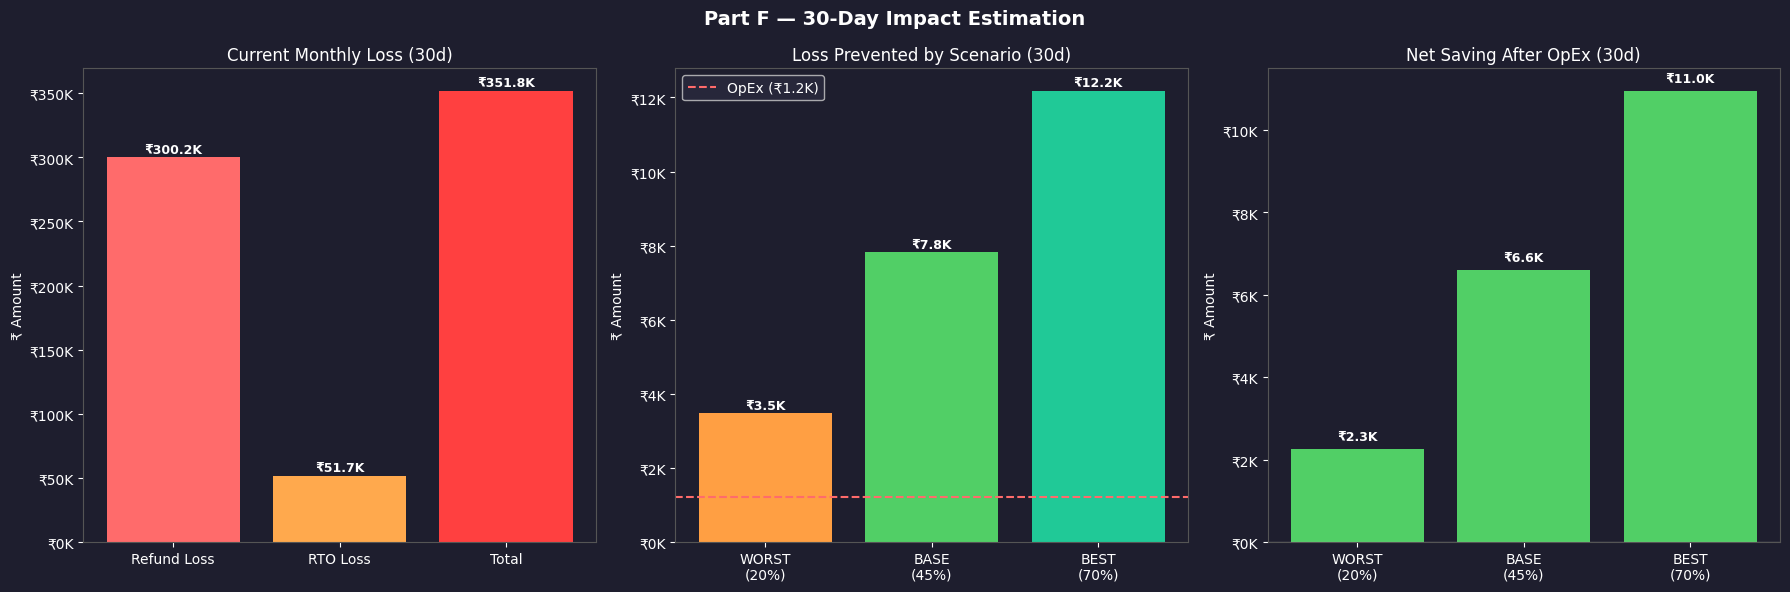

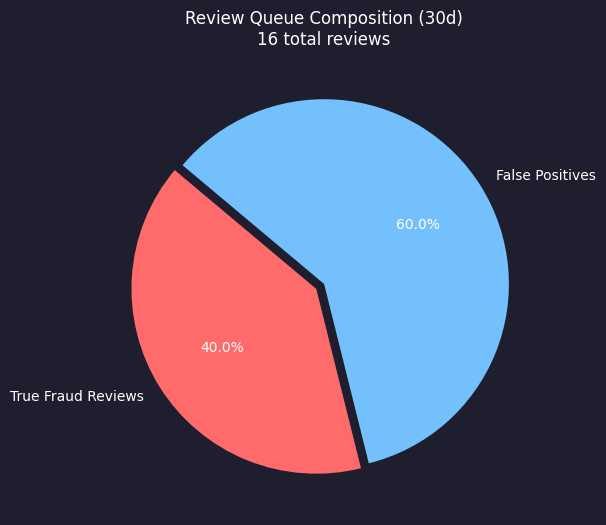

Saved impact_estimation_partF.csv with 11 rows


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


=== PART F COMPLETE ===
2 charts saved | impact_estimation_partF.csv downloaded


In [4]:
# CELL 4 — Visualizations + Save CSV + Download
from google.colab import files as colab_files

# — Build summary dataframe —
summary = pd.DataFrame([
    {'metric': 'Current Monthly Loss (Refund)',      'value_inr': refund_loss_30,      'category': 'Current Loss'},
    {'metric': 'Current Monthly Loss (RTO)',         'value_inr': rto_loss_30,         'category': 'Current Loss'},
    {'metric': 'Total Current Monthly Loss',         'value_inr': total_monthly_loss,  'category': 'Current Loss'},
    {'metric': 'Flagged Loss Pool (30d)',             'value_inr': flagged_loss_30,     'category': 'Flagged Pool'},
    {'metric': 'Loss Prevented — WORST (20%)',       'value_inr': worst_saved,         'category': 'Savings Scenario'},
    {'metric': 'Loss Prevented — BASE (45%)',        'value_inr': base_saved,          'category': 'Savings Scenario'},
    {'metric': 'Loss Prevented — BEST (70%)',        'value_inr': best_saved,          'category': 'Savings Scenario'},
    {'metric': 'OpEx Cost (30d reviews)',             'value_inr': opex_cost_30,        'category': 'Operational Cost'},
    {'metric': 'Net Saving — WORST',                 'value_inr': net_saving_worst,    'category': 'Net Impact'},
    {'metric': 'Net Saving — BASE',                  'value_inr': net_saving_base,     'category': 'Net Impact'},
    {'metric': 'Net Saving — BEST',                  'value_inr': net_saving_best,     'category': 'Net Impact'},
])
summary['value_inr'] = summary['value_inr'].round(0)
print(summary.to_string(index=False))

# — CHART 1: Loss Breakdown (Waterfall-style grouped bar) —
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Part F — 30-Day Impact Estimation', fontsize=14, color='white', fontweight='bold')

# Chart 1a: Current loss breakdown
ax = axes[0]
cats  = ['Refund Loss', 'RTO Loss', 'Total']
vals  = [refund_loss_30, rto_loss_30, total_monthly_loss]
cols  = ['#ff6b6b', '#ffa94d', '#ff4040']
bars  = ax.bar(cats, vals, color=cols)
ax.set_title('Current Monthly Loss (30d)', color='white')
ax.set_ylabel('₹ Amount')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total_monthly_loss*0.01,
            f'₹{v/1000:.1f}K', ha='center', color='white', fontsize=9, fontweight='bold')

# Chart 1b: Savings scenarios
ax = axes[1]
scenarios = ['WORST\n(20%)', 'BASE\n(45%)', 'BEST\n(70%)']
worse = [worst_saved, base_saved, best_saved]
cols2 = ['#ff9f43', '#51cf66', '#20c997']
bars2 = ax.bar(scenarios, worse, color=cols2)
ax.axhline(y=opex_cost_30, color='#ff6b6b', linestyle='--', linewidth=1.5, label=f'OpEx (₹{opex_cost_30/1000:.1f}K)')
ax.set_title('Loss Prevented by Scenario (30d)', color='white')
ax.set_ylabel('₹ Amount')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
ax.legend(facecolor='#2a2a3e', labelcolor='white')
for bar, v in zip(bars2, worse):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(worse)*0.01,
            f'₹{v/1000:.1f}K', ha='center', color='white', fontsize=9, fontweight='bold')

# Chart 1c: Net saving (could be negative in worst)
ax = axes[2]
net_vals = [net_saving_worst, net_saving_base, net_saving_best]
cols3 = ['#ff6b6b' if v < 0 else '#51cf66' for v in net_vals]
bars3 = ax.bar(scenarios, net_vals, color=cols3)
ax.axhline(y=0, color='white', linewidth=0.8, linestyle='-')
ax.set_title('Net Saving After OpEx (30d)', color='white')
ax.set_ylabel('₹ Amount')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1000:.0f}K'))
for bar, v in zip(bars3, net_vals):
    ypos = bar.get_height() + max(net_vals)*0.02 if v >= 0 else bar.get_height() - max(abs(min(net_vals)), max(net_vals))*0.08
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'₹{v/1000:.1f}K', ha='center', color='white', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('partF_impact_estimation.png', dpi=120, bbox_inches='tight')
plt.show()

# — CHART 2: Pie — Operational breakdown —
fig2, ax2 = plt.subplots(figsize=(7, 6))
fig2.patch.set_facecolor('#1e1e2e')
ax2.set_facecolor('#1e1e2e')
labels2 = ['True Fraud Reviews', 'False Positives']
sizes2  = [true_fraud_30, false_pos_30]
cols4   = ['#ff6b6b', '#74c0fc']
explode = (0.05, 0)
ax2.pie(sizes2, labels=labels2, colors=cols4, explode=explode, autopct='%1.1f%%',
        textprops={'color': 'white'}, startangle=140)
ax2.set_title(f'Review Queue Composition (30d)\n{reviews_needed_30:.0f} total reviews', color='white')
plt.savefig('partF_review_composition.png', dpi=120, bbox_inches='tight')
plt.show()

# — Save CSV —
summary.to_csv('/content/impact_estimation_partF.csv', index=False)
print(f'Saved impact_estimation_partF.csv with {len(summary)} rows')
colab_files.download('/content/impact_estimation_partF.csv')

print('\n=== PART F COMPLETE ===')
print('2 charts saved | impact_estimation_partF.csv downloaded')